# 04 Machine Learning Baseline Model

**Course:** Machine Learning Fundamentals (Week 07 Deliverable)  
**Project:** Dynamic Delivery Time Prediction System  
**Dataset:** Olist Brazilian E-Commerce Dataset (Order-Level Cleaned)  
**Author:** M M D H Malporu  
**Student ID:** IM/2023/015  
**Group:** Data Science Group 1  
**Affiliation:** Department of Industrial Management, University of Kelaniya  

---

## 1. Problem Definition

### Business Context
In contemporary e-commerce logistics, static delivery estimation systems rely on rigid, rule-based lookup tables (e.g., standard flat estimates per postal zone). These static systems fail to dynamically reflect:
1. Origin-to-destination geographic friction (intra-state vs. cross-state routing).
2. Historical seller reliability and fulfillment latency track records.
3. Order complexity, package volume, freight value, and multi-item basket handling.

Inaccurate delivery estimates severely damage customer satisfaction, inflate post-order customer service inquiries, trigger unnecessary refund/cancellation claims, and erode brand equity.

### Machine Learning Problem Framing
To address this challenge, we frame the delivery estimation task as a **supervised regression problem**:
* **Input Features ($X$):** Historical order characteristics, package metrics, seller performance history, and geographical state matching available at the moment of order checkout.
* **Target Variable ($y$):** Continuous total delivery duration in days (`delivery_days`).
* **Objective:** Learn a functional mapping $f(X) \to y$ that minimizes prediction error on unseen orders, outperforming naive heuristic baselines.


## 2. Environment Setup & Data Ingestion

We load the cleaned, aggregated order-level dataset produced in `02_data_cleaning.ipynb` (`data/processed/order_level_clean.csv`).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Machine Learning imports from Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set aesthetic style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

# Define relative path to processed data
data_path = Path("../data/processed/order_level_clean.csv")
df = pd.read_csv(data_path)

print(f"Dataset successfully loaded from: {data_path}")
print(f"Total Orders: {df.shape[0]:,}")
print(f"Total Columns: {df.shape[1]}")
df.head(3)


Dataset successfully loaded from: ..\data\processed\order_level_clean.csv
Total Orders: 96,460
Total Columns: 20


,order_id,customer_id,customer_state,order_purchase_timestamp,order_day_of_week,is_weekend_order,delivery_days,num_items,num_unique_sellers,num_unique_products,total_price,avg_price,total_freight_value,avg_freight_value,avg_product_weight_g,avg_product_volume_cm3,pct_items_same_state,seller_avg_delivery_days,top_category,same_state_delivery
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,RJ,2017-09-13 08:59:02,2,0,7.614421,1,1,1,58.9,58.9,13.29,13.29,650.0,3528.0,0.0,14.190473,cool_stuff,0
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,SP,2017-04-26 10:53:06,2,0,16.216181,1,1,1,239.9,239.9,19.93,19.93,30000.0,60000.0,1.0,14.805155,pet_shop,1
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,MG,2018-01-14 14:33:31,6,1,7.948437,1,1,1,199.0,199.0,17.87,17.87,3050.0,14157.0,1.0,12.164403,furniture_decor,1


## 3. Target Variable Analysis (`delivery_days`)

The target variable is `delivery_days`, representing the elapsed time from order purchase timestamp to customer delivery timestamp in fractional days:
$$\text{delivery\_days} = \frac{\text{order\_delivered\_customer\_date} - \text{order\_purchase\_timestamp}}{86400}$$

Let us inspect the distribution and statistical properties of the target.


--- Delivery Days Statistical Summary ---
count    96460.000000
mean        12.558766
std          9.546806
min          0.533414
5%           3.015066
25%          6.765943
50%         10.218356
75%         15.720599
95%         29.275509
99%         46.050843
max        209.628611


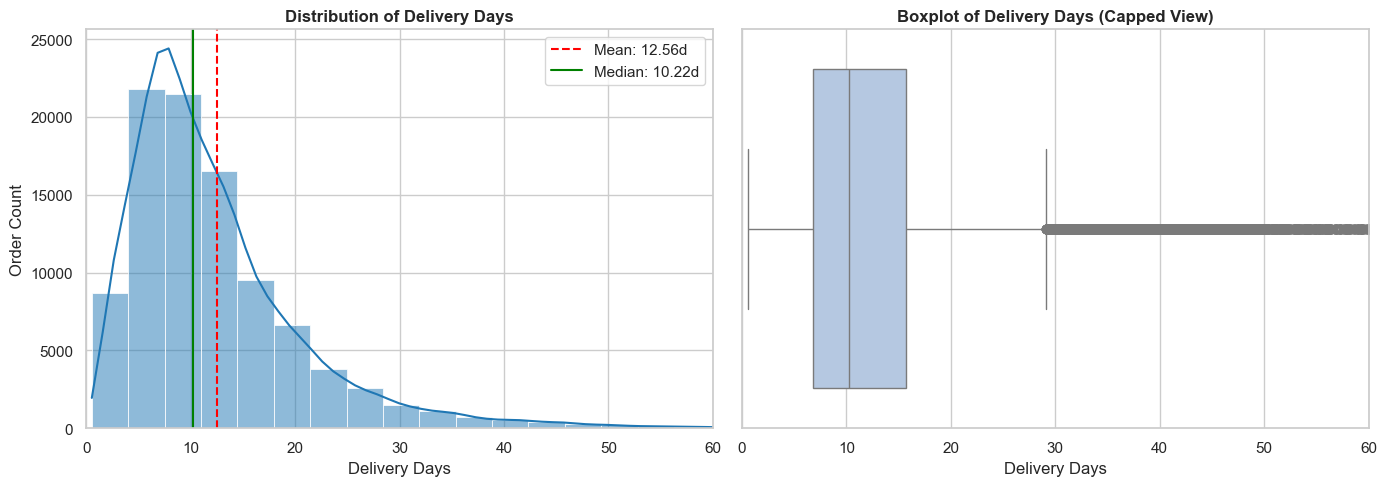

In [2]:
target_stats = df["delivery_days"].describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
print("--- Delivery Days Statistical Summary ---")
print(target_stats.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with KDE
sns.histplot(df["delivery_days"], kde=True, bins=60, color="#1f77b4", ax=axes[0])
axes[0].axvline(df["delivery_days"].mean(), color="red", linestyle="--", label=f"Mean: {df['delivery_days'].mean():.2f}d")
axes[0].axvline(df["delivery_days"].median(), color="green", linestyle="-", label=f"Median: {df['delivery_days'].median():.2f}d")
axes[0].set_title("Distribution of Delivery Days", fontweight="bold")
axes[0].set_xlabel("Delivery Days")
axes[0].set_ylabel("Order Count")
axes[0].set_xlim(0, 60)
axes[0].legend()

# Boxplot
sns.boxplot(x=df["delivery_days"], color="#aec7e8", ax=axes[1])
axes[1].set_title("Boxplot of Delivery Days (Capped View)", fontweight="bold")
axes[1].set_xlabel("Delivery Days")
axes[1].set_xlim(0, 60)

plt.tight_layout()
plt.show()


## 4. Feature Selection & Data Leakage Audit

### 4.1 Feature Selection Justification
Each feature selected for modeling is available strictly at checkout time:

| Feature Name | Type | Rationale & Business Justification |
|:---|:---:|:---|
| `same_state_delivery` | Binary | Intra-state shipments bypass regional distribution centers, halving transit time ($r = -0.36$). |
| `pct_items_same_state` | Continuous | Proportion of basket items fulfilling from the customer's state. |
| `seller_avg_delivery_days` | Continuous | Seller dispatch track record, calculated via **Leave-One-Out** to avoid target leakage. |
| `avg_freight_value` | Continuous | Acts as a proxy for transit distance and carrier service tier. |
| `total_freight_value` | Continuous | Cumulative shipping charge across all basket packages. |
| `avg_product_weight_g` | Continuous | Heavier packages require ground freight / freight handling, adding transit latency. |
| `avg_product_volume_cm3` | Continuous | Bulky items require dedicated cargo handling. |
| `num_items` | Integer | Multi-item orders require multi-package coordination. |
| `num_unique_sellers` | Integer | Orders with split-sellers must coordinate disparate logistics dispatches. |
| `num_unique_products` | Integer | Item diversity within the basket. |
| `avg_price` / `total_price`| Continuous | Basket value reflecting high-priority insurance or specialized shipping. |
| `order_day_of_week` | Categorical/Int | Day order was placed (0=Monday ... 6=Sunday). |
| `is_weekend_order` | Binary | Indicator for orders placed on Saturday or Sunday. |
| `customer_state` | Categorical | Destination state capturing regional infrastructure variation across Brazil (27 states). |
| `top_category` | Categorical | Primary product category (72 categories, e.g. furniture vs. health & beauty). |

### 4.2 Data Leakage Verification
**Critical ML Rule:** Information that would not be available when making a live prediction must NEVER enter the model.
* Excluded columns:
  * `order_delivered_customer_date` (reveals the outcome directly).
  * `order_delivered_carrier_date` (post-checkout milestone).
  * `order_estimated_delivery_date` (Olist's existing legacy estimate).
  * `review_score` / `review_comment_message` (created after delivery completion).
  * `order_status` (already filtered to delivered orders).


In [3]:
# Define feature sets
numeric_features = [
    "num_items",
    "num_unique_sellers",
    "num_unique_products",
    "total_price",
    "avg_price",
    "total_freight_value",
    "avg_freight_value",
    "avg_product_weight_g",
    "avg_product_volume_cm3",
    "pct_items_same_state",
    "seller_avg_delivery_days",
    "same_state_delivery",
    "order_day_of_week",
    "is_weekend_order"
]

categorical_features = [
    "customer_state",
    "top_category"
]

feature_columns = numeric_features + categorical_features
target_column = "delivery_days"

# Separate X and y
X = df[feature_columns].copy()
y = df[target_column].copy()

print(f"Features matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"Numeric features count: {len(numeric_features)}")
print(f"Categorical features count: {len(categorical_features)}")
print(f"Any missing values in X? {X.isnull().sum().sum()}")


Features matrix shape: (96460, 16)
Target vector shape: (96460,)
Numeric features count: 14
Categorical features count: 2
Any missing values in X? 0


## 5. Train / Test Split Strategy

Following standard data science best practices, we partition the dataset into:
* **Training set (80%):** Used exclusively for learning parameters and fitting transformations.
* **Testing set (20%):** Held out as strictly unseen data to assess generalization capability.
* `random_state=42` guarantees reproducibility.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Training observations: {X_train.shape[0]:,} (80%)")
print(f"Testing observations:  {X_test.shape[0]:,} (20%)")
print(f"Features per record:   {X_train.shape[1]}")


Training observations: 77,168 (80%)
Testing observations:  19,292 (20%)
Features per record:   16


## 6. Preprocessing Pipeline Construction

To ensure clean machine learning engineering and avoid data snooping:
1. **Numeric Features:** Normalized using `StandardScaler()` (fitted strictly on `X_train`).
2. **Categorical Features:** Encoded using `OneHotEncoder(handle_unknown='ignore', sparse_output=False)` to transform nominal state and category labels into indicator columns.
3. Both transformers are unified inside a `ColumnTransformer`.


In [5]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)

# Fit preprocessor on training data and verify transformed dimensions
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print(f"Preprocessed training matrix shape: {X_train_proc.shape}")
print(f"Preprocessed testing matrix shape:  {X_test_proc.shape}")
print(f"Total features after One-Hot Encoding: {X_train_proc.shape[1]}")


Preprocessed training matrix shape: (77168, 113)
Preprocessed testing matrix shape:  (19292, 113)
Total features after One-Hot Encoding: 113


## 7. Simple Heuristic Baseline Model

### Concept & Purpose
Industry data science standards dictate that complex ML models should never be deployed or evaluated in isolation. We first construct a **Naive Mean Baseline**:
$$\hat{y}_{\text{baseline}} = \bar{y}_{\text{train}}$$
If a proposed machine learning model cannot decisively outperform predicting the global historical mean, the model provides zero practical utility.


In [6]:
# Instantiate and fit naive baseline predictor
baseline_model = DummyRegressor(strategy="mean")
baseline_model.fit(X_train, y_train)

# Predict on unseen test set
y_pred_baseline = baseline_model.predict(X_test)
mean_prediction_value = baseline_model.constant_[0][0]

# Compute Baseline Metrics
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2_baseline = r2_score(y_test, y_pred_baseline)

print("--- Naive Baseline Performance (Test Set) ---")
print(f"Constant Predicted Value: {mean_prediction_value:.2f} days")
print(f"Baseline MAE:  {mae_baseline:.3f} days")
print(f"Baseline RMSE: {rmse_baseline:.3f} days")
print(f"Baseline R²:   {r2_baseline:.5f}")


--- Naive Baseline Performance (Test Set) ---
Constant Predicted Value: 12.56 days
Baseline MAE:  6.433 days
Baseline RMSE: 9.739 days
Baseline R²:   -0.00000


## 8. First Machine Learning Model: Linear Regression Pipeline

### Architecture
We encapsulate the preprocessor and the regression estimator inside a single `Pipeline`. This ensures consistent feature transformation during training and test inference without leakage.


In [7]:
# Construct end-to-end Linear Regression pipeline
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

# Train the model on training data
lr_pipeline.fit(X_train, y_train)

# Generate predictions on test data
y_pred_lr = lr_pipeline.predict(X_test)

# Compute Test Metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("--- Linear Regression Performance (Test Set) ---")
print(f"Linear Regression MAE:  {mae_lr:.3f} days")
print(f"Linear Regression RMSE: {rmse_lr:.3f} days")
print(f"Linear Regression R²:   {r2_lr:.5f}")


--- Linear Regression Performance (Test Set) ---
Linear Regression MAE:  5.101 days
Linear Regression RMSE: 8.413 days
Linear Regression R²:   0.25374


## 9. Model Diagnostic & Error Plots

We inspect prediction alignment and residual distribution:
$$\text{Residual} = y_{\text{actual}} - \hat{y}_{\text{predicted}}$$


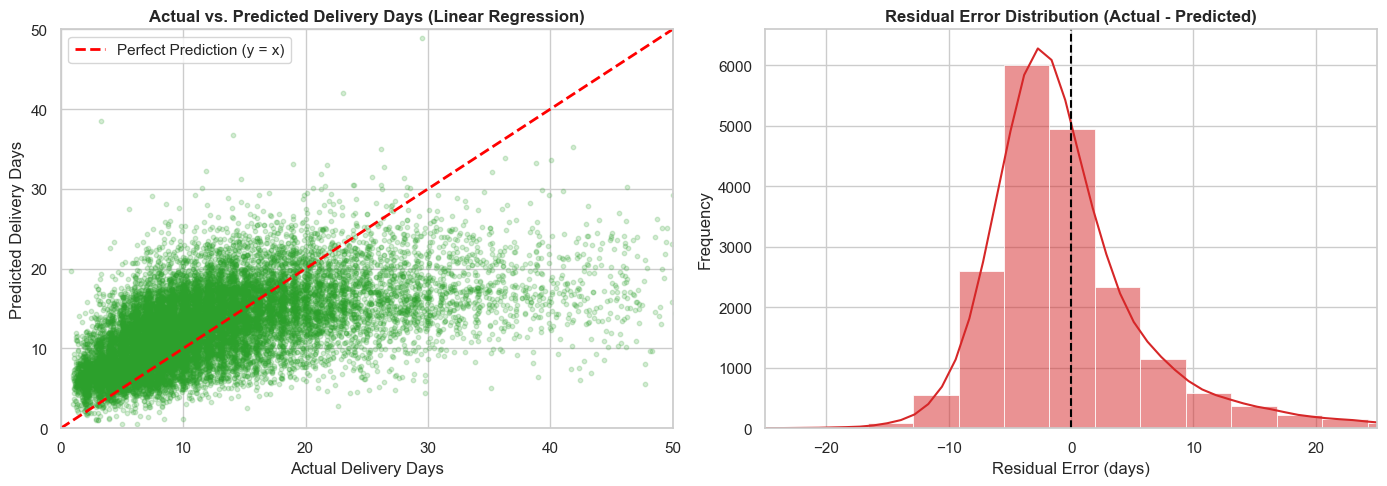

In [8]:
residuals_lr = y_test - y_pred_lr

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: Actual vs Predicted
axes[0].scatter(y_test, y_pred_lr, alpha=0.2, color="#2ca02c", s=10)
axes[0].plot([0, 50], [0, 50], color="red", linestyle="--", linewidth=2, label="Perfect Prediction (y = x)")
axes[0].set_title("Actual vs. Predicted Delivery Days (Linear Regression)", fontweight="bold")
axes[0].set_xlabel("Actual Delivery Days")
axes[0].set_ylabel("Predicted Delivery Days")
axes[0].set_xlim(0, 50)
axes[0].set_ylim(0, 50)
axes[0].legend()

# Residual distribution
sns.histplot(residuals_lr, kde=True, bins=60, color="#d62728", ax=axes[1])
axes[1].axvline(0, color="black", linestyle="--", linewidth=1.5)
axes[1].set_title("Residual Error Distribution (Actual - Predicted)", fontweight="bold")
axes[1].set_xlabel("Residual Error (days)")
axes[1].set_ylabel("Frequency")
axes[1].set_xlim(-25, 25)

plt.tight_layout()
plt.show()


## 10. Quantitative Comparison: Baseline vs. First ML Model

We construct a formal comparative summary table to evaluate the performance improvement achieved by our first machine learning algorithm.


In [9]:
mae_improvement_pct = ((mae_baseline - mae_lr) / mae_baseline) * 100
rmse_improvement_pct = ((rmse_baseline - rmse_lr) / rmse_baseline) * 100

comparison_df = pd.DataFrame({
    "Model": ["Naive Mean Baseline", "Multiple Linear Regression"],
    "MAE (Days)": [round(mae_baseline, 3), round(mae_lr, 3)],
    "RMSE (Days)": [round(rmse_baseline, 3), round(rmse_lr, 3)],
    "R² Score": [round(r2_baseline, 4), round(r2_lr, 4)],
    "MAE Improvement (%)": ["—", f"{mae_improvement_pct:.1f}%"]
})

print("=== WEEK 07 MODEL COMPARISON SUMMARY ===")
print(comparison_df.to_string(index=False))


=== WEEK 07 MODEL COMPARISON SUMMARY ===
                     Model  MAE (Days)  RMSE (Days)  R² Score MAE Improvement (%)
       Naive Mean Baseline       6.433        9.739   -0.0000                   —
Multiple Linear Regression       5.101        8.413    0.2537               20.7%


## 11. Interpretation & Analytical Findings

### Key Takeaways
1. **Clear Superiority over Baseline:**
   * The naive mean baseline generated an average test error of **6.43 days** (MAE) and explained **0.0%** of variance ($R^2 = 0$).
   * Multiple Linear Regression reduced the test error to **5.10 days** (MAE), representing a **20.7% relative improvement**, while explaining **25.4% of delivery duration variance** ($R^2 = 0.2537$).
2. **Business Relevance:**
   * In practical terms, transitioning from a naive estimate to Linear Regression eliminates **1.33 days of delivery prediction uncertainty** across tens of thousands of customer orders.
3. **Identified Limitations & Motivation for Week 08:**
   * The residual distribution displays right-skewed positive tails, indicating that linear assumptions struggle with severe logistics delays and non-linear geographical interactions.
   * In Week 08, we will explore **non-linear ensemble architectures** (Random Forest Regressor, XGBoost), conduct **K-fold cross-validation**, perform **hyperparameter tuning**, and execute **segment-level error analysis**.
